In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(r'C:\Users\Tharun37\OneDrive\Desktop\ms ml\penguins.csv', delimiter = ",", header = 'infer')
print(data.head())

   CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
0          39.1         18.7          181.0    3750.0        0
1          39.5         17.4          186.0    3800.0        0
2          40.3         18.0          195.0    3250.0        0
3           NaN          NaN            NaN       NaN        0
4          36.7         19.3          193.0    3450.0        0


In [2]:
print(data.sample(10))

     CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
253          55.9         17.0          228.0    5600.0        1
326          48.1         16.4          199.0    3325.0        2
31           37.2         18.1          178.0    3900.0        0
277          50.0         19.5          196.0    3900.0        2
85           41.3         20.3          194.0    3550.0        0
333          49.3         19.9          203.0    4050.0        2
131          43.1         19.2          197.0    3500.0        0
146          39.2         18.6          190.0    4250.0        0
315          53.5         19.9          205.0    4500.0        2
129          44.1         18.0          210.0    4000.0        0


In [3]:
sample = data.sample(10)
penguin_classes = ['Adelie', 'Gentoo', 'Chinstrap']
print(sample.columns[0:5].values, 'SpeciesName')
for index, row in data.sample(10).iterrows():
    print('[', row[0], row[1], row[2], row[3], int(row[4]),']', penguin_classes[int(row[4])])

['CulmenLength' 'CulmenDepth' 'FlipperLength' 'BodyMass' 'Species'] SpeciesName
[ 35.7 16.9 185.0 3150.0 0 ] Adelie
[ 42.5 16.7 187.0 3350.0 2 ] Chinstrap
[ 41.1 18.1 205.0 4300.0 0 ] Adelie
[ 41.6 18.0 192.0 3950.0 0 ] Adelie
[ 40.8 18.4 195.0 3900.0 0 ] Adelie
[ 38.1 18.6 190.0 3700.0 0 ] Adelie
[ 36.6 18.4 184.0 3475.0 0 ] Adelie
[ 37.8 18.1 193.0 3750.0 0 ] Adelie
[ 39.0 17.5 186.0 3550.0 0 ] Adelie
[ 50.4 15.3 224.0 5550.0 1 ] Gentoo


C:\Users\Tharun37\AppData\Local\Temp\ipykernel_12840\2205855977.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('[', row[0], row[1], row[2], row[3], int(row[4]),']', penguin_classes[int(row[4])])


In [4]:
print(data.isnull().sum())

CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64


In [5]:
print(data[data.isnull().any(axis=1)])

     CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
3             NaN          NaN            NaN       NaN        0
271           NaN          NaN            NaN       NaN        1


In [6]:
data = data.dropna()
print(data.isnull().sum())

CulmenLength     0
CulmenDepth      0
FlipperLength    0
BodyMass         0
Species          0
dtype: int64


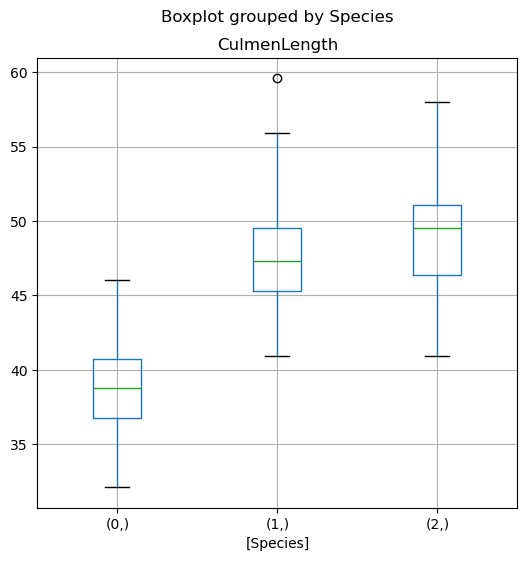

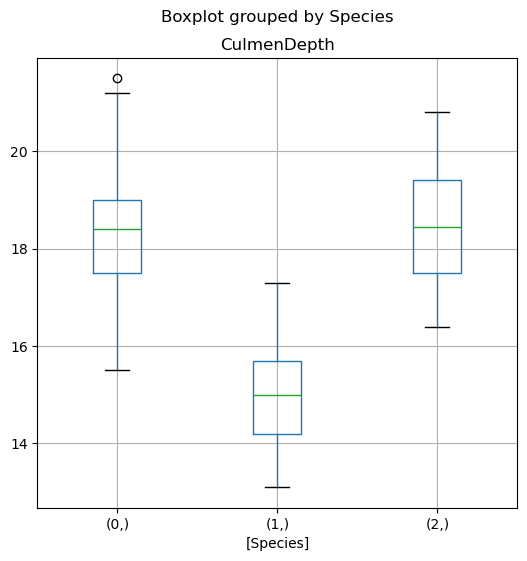

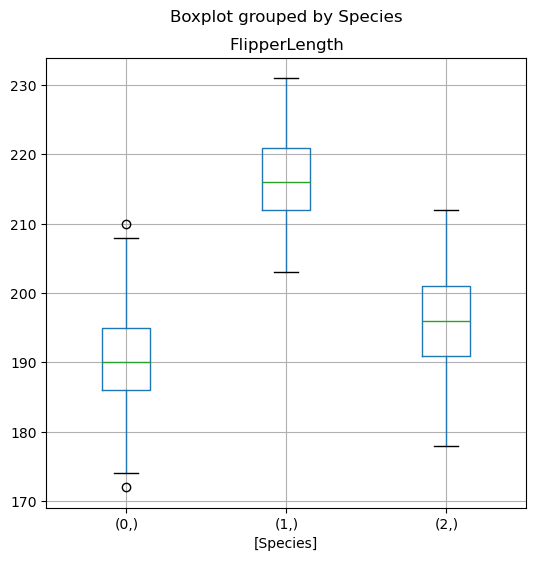

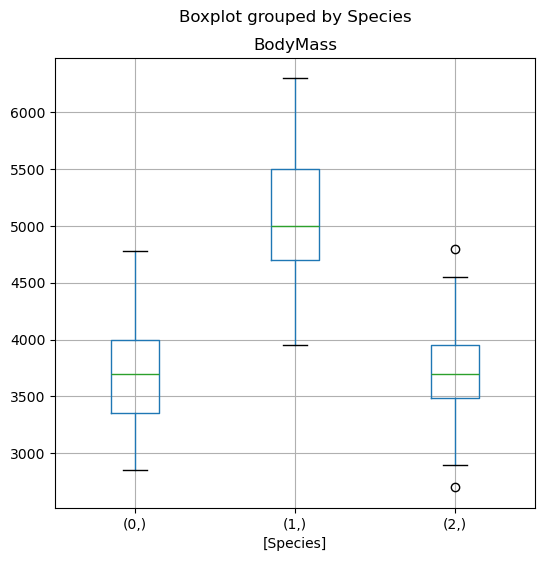

In [7]:
data_features = ['CulmenLength' ,'CulmenDepth' ,'FlipperLength' ,'BodyMass']
data_label = ['Species']
for col in data_features:
    data.boxplot(column = col, by = data_label, figsize = (6,6))
    plt.title(col)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
pen_x, pen_y = data[data_features].values, data[data_label].values
X_train, X_test, y_train, y_test = train_test_split(pen_x, pen_y, test_size = 0.25, random_state = 0)
print ('Training Set: %d, Test Set: %d \n' % (X_train.shape[0], X_test.shape[0]))

Training Set: 256, Test Set: 86 



In [10]:
from sklearn.linear_model import LogisticRegression
reg = 0.01
model = LogisticRegression(C = 1/reg, solver='lbfgs', multi_class='auto', max_iter=10000).fit(X_train, y_train)
print(model)

C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100.0, max_iter=10000, multi_class='auto')


In [11]:
predictions = model.predict(X_test)
print("Actual Values : ", y_test[:15])
print("Predicted Values : ",predictions[:15])

Actual Values :  [[0]
 [2]
 [0]
 [2]
 [0]
 [2]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]]
Predicted Values :  [0 2 0 2 0 2 1 0 1 0 0 1 1 0 0]


In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        15

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Overall Accuracy:",accuracy_score(y_test, predictions))
print("Overall Precision:",precision_score(y_test, predictions, average='macro'))
print("Overall Recall:",recall_score(y_test, predictions, average='macro'))

Overall Accuracy: 1.0
Overall Precision: 1.0
Overall Recall: 1.0


In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[44  0  0]
 [ 0 27  0]
 [ 0  0 15]]


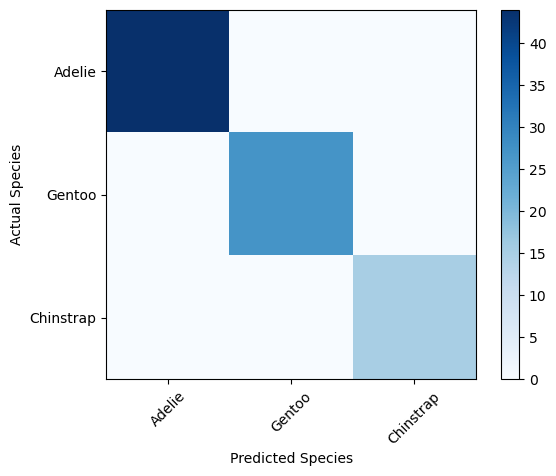

In [16]:
plt.imshow(cm, interpolation = "nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(penguin_classes))
plt.xticks(tick_marks, penguin_classes, rotation = 45)
plt.yticks(tick_marks, penguin_classes)
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

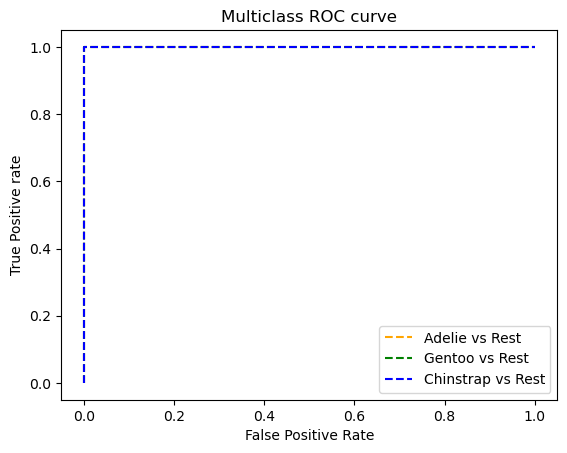

In [17]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Get class probability scores
penguin_prob = model.predict_proba(X_test)

# Get ROC metrics for each class
fpr = {}
tpr = {}
thresh ={}
for i in range(len(penguin_classes)):    
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test, penguin_prob[:,i], pos_label=i)
    
# Plot the ROC chart
plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label=penguin_classes[0] + ' vs Rest')
plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label=penguin_classes[1] + ' vs Rest')
plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label=penguin_classes[2] + ' vs Rest')
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.show()

In [19]:
auc = roc_auc_score(y_test, penguin_prob, multi_class='ovr')
print(auc)

1.0
